# ExProf-Bench T3: Six Elements Test (Prospective Memory + Strategic Task Management)
**Kaggle AGI Hackathon 2026** | Track: Executive Functions | Google DeepMind × Kaggle

T3 evaluates **prospective memory and strategic task management** using the Modified Six Elements Test (BADS, Wilson et al., 1996; Shallice & Burgess, 1991). Each item presents N sub-tasks (two parts each), a shared step budget, and one alternation rule. The model must plan a work sequence that covers all sub-tasks without violating the alternation constraint and without exceeding the budget — without being told explicitly to "cover every sub-task".

**Discriminant design**: HARD and EXTREME items list one task as "HIGH PRIORITY / CRITICAL" to induce task monopolisation — the canonical inhibitory control failure in the Six Elements paradigm. The model must suppress this prepotent response to maintain broad coverage. The prompt does not remind the model of the coverage goal, replicating the prospective memory load of the original instrument.

## Scoring and EPI

**Global Executive Performance Impairment (EPI):**
$$ EPI = \frac{TEI + PV + (1 - TSO) + (1 - IS) + TVR + \frac{ER + (1 - PD)}{2}}{6} $$

*Where:*
- **TEI**: Task-set Error Index (T1 — Inhibitory Control)
- **PV**: Protocol Violation rate (T2 — Look-Ahead Planning)
- **1 − TSO**: Impaired Task Sequence Optimization (T3 — Prospective Memory / Six Elements)
- **1 − IS**: Impaired Systematicity Index (T4 — Monitoring / Systematic Search)
- **TVR**: Trail Violation Rate (T5 — Cognitive Flexibility / Set-Shifting)
- **ER**: Spatial Error Rate / **PD**: Precision Degradation (T6 — Visuospatial WM + Dual-Task)

*Direction:* 0 = no impairment (best), 1 = total failure (worst).

**Normative Anchor (EPI Range):**
- `< 0.20`: Healthy adult baseline (BRIEF-2A, n=1,637)
- `0.20 - 0.40`: Executive borderline zone
- `> 0.40`: Mild to severe executive dysfunction

### Passing criteria (>= 0.70 pass rate)
To pass, the model must score ≥ 0.70 on at least 70% of items.

### Per-item scoring (3 axes, deterministic)
| Axis | Weight | Condition |
|------|--------|-----------|
| `sequence_ok` | 0.40 | No two consecutive sub-tasks share the same task-type |
| `coverage_ok` | 0.40 | Every sub-task appears at least once in the sequence |
| `budget_ok`   | 0.20 | Total sequence length ≤ budget\_steps |

Self-correction detected → score = 0.0 (Rule 0: first committed response is scored).

### TSO component
`TSO = mean(score_item)` across all 20 items. `1 − TSO` enters the EPI formula as the T3 impairment index.


In [1]:
# [AUTOGENERATED] Clear Kaggle SDK cache to force live evaluation
!rm -f *.run.json *.task.json *.png

import kaggle_benchmarks as kbench
import re, json as _jj, os as _os
from collections import defaultdict
try:
    import matplotlib
except ImportError:
    import subprocess, sys as _sys
    subprocess.check_call([_sys.executable, '-m', 'pip', 'install', 'matplotlib', '-q'])

GLOBAL_RESULTS_T3 = []

EF_DIMENSION_T3 = {
    'TASK_MONOPOLISATION':  'Inhibitory Control (cross-load)',
    'COVERAGE_NEGLECT':     'Prospective Memory — coverage failure',
    'CONSECUTIVE_REPEAT':   'Shifting — alternation failure',
    'BUDGET_OVERFLOW':      'Working Memory — time management failure',
    'COMBINED_FAILURE':     'Combined EF Load',
    'NONE':                 'Prospective Memory + Strategic Task Management',
}

print('ExProf-Bench T3 — Six Elements Test ready.')


ExProf-Bench T3 — Six Elements Test ready.


In [2]:
"""
T3 - SixElements  |  ExProf-Bench
EF Primary  : Prospective Memory + Strategic Task Management
EF Cross-load: Inhibitory Control (suppressing task monopolisation)
               Shifting (mandatory alternation rule)
               Working Memory (tracking all active task slots)
Reference   : Modified Six Elements Test — BADS (Wilson et al., 1996)
              Shallice & Burgess (1991) | Miyake et al. (2000)
20 items    : 5 EASY · 5 MEDIUM · 5 HARD · 5 EXTREME

Paradigm
--------
Each item presents N task-types (each with two parts: A and B).
The model receives a step budget and ONE rule stated at the top of the prompt.
It must plan a step sequence and return it as JSON.

Discriminant design
-------------------
- The prompt does NOT tell the model to "cover every sub-task" —
  it only says "complete the work session as effectively as possible".
  The model must infer from the goal that all sub-tasks need attention.
- HARD/EXTREME: the monopolisation bait is listed first and framed as "urgent",
  triggering the inhibitory control failure (model fixates on it).
- EXTREME: budget = len(subtasks) + 1 (one slack step only).
  Any sequence longer than budget OR missing any sub-task fails.
- Self-correction detected -> score 0.0 (Rule 0).

Evaluator axes (deterministic)
-------------------------------
  coverage_ok  (0/1): every sub-task appears >= 1 time  -> weight 0.40
  sequence_ok  (0/1): no two consecutive entries share task-type -> weight 0.40
  budget_ok    (0/1): len(sequence) <= budget_steps  -> weight 0.20
  score = 0.40*sequence_ok + 0.40*coverage_ok + 0.20*budget_ok
  pass  = score >= 0.70
"""

T3_TASKS_DATA = [
    # ══════════════════════════════════════════════════════════════════
    # EASY — 3 task-types (6 sub-tasks) | budget = 9 (3 slack steps)
    # Prompt: neutral framing, no urgency, rule stated plainly
    # Expected failure mode at this level: essentially none for capable models
    # ══════════════════════════════════════════════════════════════════
    {
        "id": "t3_easy_01", "difficulty": "EASY",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "NONE",
        "task_types": ["Dictation", "Arithmetic", "Naming"],
        "subtasks": ["Dictation_A", "Dictation_B", "Arithmetic_A",
                     "Arithmetic_B", "Naming_A", "Naming_B"],
        "budget_steps": 9,
        "monopolisation_bait": None,
        "ground_truth_example": ["Dictation_A","Arithmetic_A","Naming_A",
                                  "Dictation_B","Arithmetic_B","Naming_B"],
    },
    {
        "id": "t3_easy_02", "difficulty": "EASY",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "NONE",
        "task_types": ["Copying", "Calculation", "Recall"],
        "subtasks": ["Copying_A","Copying_B","Calculation_A",
                     "Calculation_B","Recall_A","Recall_B"],
        "budget_steps": 9,
        "monopolisation_bait": None,
        "ground_truth_example": ["Copying_A","Calculation_A","Recall_A",
                                  "Copying_B","Calculation_B","Recall_B"],
    },
    {
        "id": "t3_easy_03", "difficulty": "EASY",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "NONE",
        "task_types": ["Reading", "Sorting", "Drawing"],
        "subtasks": ["Reading_A","Reading_B","Sorting_A",
                     "Sorting_B","Drawing_A","Drawing_B"],
        "budget_steps": 9,
        "monopolisation_bait": None,
        "ground_truth_example": ["Reading_A","Sorting_A","Drawing_A",
                                  "Reading_B","Sorting_B","Drawing_B"],
    },
    {
        "id": "t3_easy_04", "difficulty": "EASY",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "NONE",
        "task_types": ["Labelling", "Counting", "Writing"],
        "subtasks": ["Labelling_A","Labelling_B","Counting_A",
                     "Counting_B","Writing_A","Writing_B"],
        "budget_steps": 9,
        "monopolisation_bait": None,
        "ground_truth_example": ["Labelling_A","Counting_A","Writing_A",
                                  "Labelling_B","Counting_B","Writing_B"],
    },
    {
        "id": "t3_easy_05", "difficulty": "EASY",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "NONE",
        "task_types": ["Matching", "Transcribing", "Estimating"],
        "subtasks": ["Matching_A","Matching_B","Transcribing_A",
                     "Transcribing_B","Estimating_A","Estimating_B"],
        "budget_steps": 9,
        "monopolisation_bait": None,
        "ground_truth_example": ["Matching_A","Transcribing_A","Estimating_A",
                                  "Matching_B","Transcribing_B","Estimating_B"],
    },
    # ══════════════════════════════════════════════════════════════════
    # MEDIUM — 4 task-types (8 sub-tasks) | budget = 10 (2 slack steps)
    # Trap: COVERAGE_NEGLECT — budget tighter, 8 required steps out of 10
    # Prompt does NOT list goal explicitly -> model must track all slots
    # ══════════════════════════════════════════════════════════════════
    {
        "id": "t3_med_01", "difficulty": "MEDIUM",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "COVERAGE_NEGLECT",
        "task_types": ["Dictation", "Arithmetic", "Naming", "Copying"],
        "subtasks": ["Dictation_A","Dictation_B","Arithmetic_A","Arithmetic_B",
                     "Naming_A","Naming_B","Copying_A","Copying_B"],
        "budget_steps": 10,
        "monopolisation_bait": None,
        "ground_truth_example": ["Dictation_A","Arithmetic_A","Naming_A","Copying_A",
                                  "Dictation_B","Arithmetic_B","Naming_B","Copying_B"],
    },
    {
        "id": "t3_med_02", "difficulty": "MEDIUM",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "COVERAGE_NEGLECT",
        "task_types": ["Reading", "Calculation", "Drawing", "Sorting"],
        "subtasks": ["Reading_A","Reading_B","Calculation_A","Calculation_B",
                     "Drawing_A","Drawing_B","Sorting_A","Sorting_B"],
        "budget_steps": 10,
        "monopolisation_bait": None,
        "ground_truth_example": ["Reading_A","Calculation_A","Drawing_A","Sorting_A",
                                  "Reading_B","Calculation_B","Drawing_B","Sorting_B"],
    },
    {
        "id": "t3_med_03", "difficulty": "MEDIUM",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "COVERAGE_NEGLECT",
        "task_types": ["Labelling", "Transcribing", "Matching", "Writing"],
        "subtasks": ["Labelling_A","Labelling_B","Transcribing_A","Transcribing_B",
                     "Matching_A","Matching_B","Writing_A","Writing_B"],
        "budget_steps": 10,
        "monopolisation_bait": None,
        "ground_truth_example": ["Labelling_A","Transcribing_A","Matching_A","Writing_A",
                                  "Labelling_B","Transcribing_B","Matching_B","Writing_B"],
    },
    {
        "id": "t3_med_04", "difficulty": "MEDIUM",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "COVERAGE_NEGLECT",
        "task_types": ["Recall", "Estimating", "Counting", "Copying"],
        "subtasks": ["Recall_A","Recall_B","Estimating_A","Estimating_B",
                     "Counting_A","Counting_B","Copying_A","Copying_B"],
        "budget_steps": 10,
        "monopolisation_bait": None,
        "ground_truth_example": ["Recall_A","Estimating_A","Counting_A","Copying_A",
                                  "Recall_B","Estimating_B","Counting_B","Copying_B"],
    },
    {
        "id": "t3_med_05", "difficulty": "MEDIUM",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "COVERAGE_NEGLECT",
        "task_types": ["Dictation", "Drawing", "Sorting", "Arithmetic"],
        "subtasks": ["Dictation_A","Dictation_B","Drawing_A","Drawing_B",
                     "Sorting_A","Sorting_B","Arithmetic_A","Arithmetic_B"],
        "budget_steps": 10,
        "monopolisation_bait": None,
        "ground_truth_example": ["Dictation_A","Drawing_A","Sorting_A","Arithmetic_A",
                                  "Dictation_B","Drawing_B","Sorting_B","Arithmetic_B"],
    },
    # ══════════════════════════════════════════════════════════════════
    # HARD — 5 task-types (10 sub-tasks) | budget = 12 (2 slack steps)
    # Trap: TASK_MONOPOLISATION
    # Prompt lists bait task FIRST, marks it "high-priority / urgent"
    # Rule is stated but coverage goal is NOT stated
    # Inhibitory control failure = model spends all budget on bait
    # ══════════════════════════════════════════════════════════════════
    {
        "id": "t3_hard_01", "difficulty": "HARD",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "TASK_MONOPOLISATION",
        "task_types": ["Arithmetic", "Dictation", "Naming", "Copying", "Reading"],
        "subtasks": ["Arithmetic_A","Arithmetic_B","Dictation_A","Dictation_B",
                     "Naming_A","Naming_B","Copying_A","Copying_B","Reading_A","Reading_B"],
        "budget_steps": 12,
        "monopolisation_bait": "Arithmetic",
        "ground_truth_example": ["Arithmetic_A","Dictation_A","Naming_A","Copying_A","Reading_A",
                                  "Arithmetic_B","Dictation_B","Naming_B","Copying_B","Reading_B"],
    },
    {
        "id": "t3_hard_02", "difficulty": "HARD",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "TASK_MONOPOLISATION",
        "task_types": ["Calculation", "Drawing", "Sorting", "Matching", "Transcribing"],
        "subtasks": ["Calculation_A","Calculation_B","Drawing_A","Drawing_B",
                     "Sorting_A","Sorting_B","Matching_A","Matching_B",
                     "Transcribing_A","Transcribing_B"],
        "budget_steps": 12,
        "monopolisation_bait": "Calculation",
        "ground_truth_example": ["Calculation_A","Drawing_A","Sorting_A","Matching_A","Transcribing_A",
                                  "Calculation_B","Drawing_B","Sorting_B","Matching_B","Transcribing_B"],
    },
    {
        "id": "t3_hard_03", "difficulty": "HARD",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "TASK_MONOPOLISATION",
        "task_types": ["Writing", "Labelling", "Counting", "Recall", "Estimating"],
        "subtasks": ["Writing_A","Writing_B","Labelling_A","Labelling_B",
                     "Counting_A","Counting_B","Recall_A","Recall_B",
                     "Estimating_A","Estimating_B"],
        "budget_steps": 12,
        "monopolisation_bait": "Writing",
        "ground_truth_example": ["Writing_A","Labelling_A","Counting_A","Recall_A","Estimating_A",
                                  "Writing_B","Labelling_B","Counting_B","Recall_B","Estimating_B"],
    },
    {
        "id": "t3_hard_04", "difficulty": "HARD",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "TASK_MONOPOLISATION",
        "task_types": ["Dictation", "Arithmetic", "Copying", "Sorting", "Drawing"],
        "subtasks": ["Dictation_A","Dictation_B","Arithmetic_A","Arithmetic_B",
                     "Copying_A","Copying_B","Sorting_A","Sorting_B","Drawing_A","Drawing_B"],
        "budget_steps": 12,
        "monopolisation_bait": "Dictation",
        "ground_truth_example": ["Dictation_A","Arithmetic_A","Copying_A","Sorting_A","Drawing_A",
                                  "Dictation_B","Arithmetic_B","Copying_B","Sorting_B","Drawing_B"],
    },
    {
        "id": "t3_hard_05", "difficulty": "HARD",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "TASK_MONOPOLISATION",
        "task_types": ["Naming", "Reading", "Matching", "Transcribing", "Labelling"],
        "subtasks": ["Naming_A","Naming_B","Reading_A","Reading_B",
                     "Matching_A","Matching_B","Transcribing_A","Transcribing_B",
                     "Labelling_A","Labelling_B"],
        "budget_steps": 12,
        "monopolisation_bait": "Naming",
        "ground_truth_example": ["Naming_A","Reading_A","Matching_A","Transcribing_A","Labelling_A",
                                  "Naming_B","Reading_B","Matching_B","Transcribing_B","Labelling_B"],
    },
    # ══════════════════════════════════════════════════════════════════
    # EXTREME — 6 task-types (12 sub-tasks) | budget = 13 (1 slack step)
    # Traps: COMBINED_FAILURE
    # - Bait listed first as "CRITICAL / overdue"
    # - Budget = 13: model must cover all 12 sub-tasks with 1 extra step max
    #   Any repetition within budget crowds out coverage
    # - Rule stated once at top, no reminder
    # - Prompt uses realistic workplace scenario language (high stakes)
    # ══════════════════════════════════════════════════════════════════
    {
        "id": "t3_extreme_01", "difficulty": "EXTREME",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "COMBINED_FAILURE",
        "task_types": ["Arithmetic","Dictation","Naming","Copying","Reading","Drawing"],
        "subtasks": ["Arithmetic_A","Arithmetic_B","Dictation_A","Dictation_B",
                     "Naming_A","Naming_B","Copying_A","Copying_B",
                     "Reading_A","Reading_B","Drawing_A","Drawing_B"],
        "budget_steps": 13,
        "monopolisation_bait": "Arithmetic",
        "ground_truth_example": ["Arithmetic_A","Dictation_A","Naming_A","Copying_A","Reading_A","Drawing_A",
                                  "Arithmetic_B","Dictation_B","Naming_B","Copying_B","Reading_B","Drawing_B"],
    },
    {
        "id": "t3_extreme_02", "difficulty": "EXTREME",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "COMBINED_FAILURE",
        "task_types": ["Calculation","Sorting","Matching","Writing","Labelling","Transcribing"],
        "subtasks": ["Calculation_A","Calculation_B","Sorting_A","Sorting_B",
                     "Matching_A","Matching_B","Writing_A","Writing_B",
                     "Labelling_A","Labelling_B","Transcribing_A","Transcribing_B"],
        "budget_steps": 13,
        "monopolisation_bait": "Calculation",
        "ground_truth_example": ["Calculation_A","Sorting_A","Matching_A","Writing_A","Labelling_A","Transcribing_A",
                                  "Calculation_B","Sorting_B","Matching_B","Writing_B","Labelling_B","Transcribing_B"],
    },
    {
        "id": "t3_extreme_03", "difficulty": "EXTREME",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "COMBINED_FAILURE",
        "task_types": ["Dictation","Arithmetic","Naming","Drawing","Counting","Recall"],
        "subtasks": ["Dictation_A","Dictation_B","Arithmetic_A","Arithmetic_B",
                     "Naming_A","Naming_B","Drawing_A","Drawing_B",
                     "Counting_A","Counting_B","Recall_A","Recall_B"],
        "budget_steps": 13,
        "monopolisation_bait": "Dictation",
        "ground_truth_example": ["Dictation_A","Arithmetic_A","Naming_A","Drawing_A","Counting_A","Recall_A",
                                  "Dictation_B","Arithmetic_B","Naming_B","Drawing_B","Counting_B","Recall_B"],
    },
    {
        "id": "t3_extreme_04", "difficulty": "EXTREME",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "COMBINED_FAILURE",
        "task_types": ["Copying","Reading","Sorting","Estimating","Matching","Writing"],
        "subtasks": ["Copying_A","Copying_B","Reading_A","Reading_B",
                     "Sorting_A","Sorting_B","Estimating_A","Estimating_B",
                     "Matching_A","Matching_B","Writing_A","Writing_B"],
        "budget_steps": 13,
        "monopolisation_bait": "Copying",
        "ground_truth_example": ["Copying_A","Reading_A","Sorting_A","Estimating_A","Matching_A","Writing_A",
                                  "Copying_B","Reading_B","Sorting_B","Estimating_B","Matching_B","Writing_B"],
    },
    {
        "id": "t3_extreme_05", "difficulty": "EXTREME",
        "ef_primary": "Prospective Memory", "ef_obstacle": "Inhibitory Control",
        "cognitive_trap": "COMBINED_FAILURE",
        "task_types": ["Naming","Arithmetic","Labelling","Transcribing","Counting","Drawing"],
        "subtasks": ["Naming_A","Naming_B","Arithmetic_A","Arithmetic_B",
                     "Labelling_A","Labelling_B","Transcribing_A","Transcribing_B",
                     "Counting_A","Counting_B","Drawing_A","Drawing_B"],
        "budget_steps": 13,
        "monopolisation_bait": "Naming",
        "ground_truth_example": ["Naming_A","Arithmetic_A","Labelling_A","Transcribing_A","Counting_A","Drawing_A",
                                  "Naming_B","Arithmetic_B","Labelling_B","Transcribing_B","Counting_B","Drawing_B"],
    },
]

for item in T3_TASKS_DATA:
    assert len(item["subtasks"]) == len(item["task_types"]) * 2, f"Bad: {item['id']}"
    assert item["budget_steps"] >= len(item["subtasks"]), f"Budget impossible: {item['id']}"

print(f"T3: {len(T3_TASKS_DATA)} items validated.")
from collections import Counter
print("Difficulty:", dict(Counter(i["difficulty"] for i in T3_TASKS_DATA)))


T3: 20 items validated.
Difficulty: {'EASY': 5, 'MEDIUM': 5, 'HARD': 5, 'EXTREME': 5}


In [3]:

SC_WORDS_T3 = ['actually', 'wait,', 'correction', 'my mistake', 'revised sequence',
               'let me redo', 'corrijo', 'rectifico', 'i made an error', 'i need to reconsider']

def _self_corrected_t3(text):
    return any(kw in text.lower() for kw in SC_WORDS_T3)

def _extract_sequence(text):
    """Parse {"sequence": [...]} with fallback to any JSON object/array in text."""
    # 1. Full clean parse
    try:
        obj = _jj.loads(text.strip())
        if isinstance(obj, dict) and 'sequence' in obj:
            seq = obj['sequence']
            if isinstance(seq, list):
                return [x.strip() for x in seq if isinstance(x, str) and x.strip()]
    except Exception:
        pass
    # 2. Extract first {...} block (handles text prefix before JSON)
    i = text.find('{'); j = text.rfind('}')
    if i != -1 and j > i:
        try:
            obj = _jj.loads(text[i:j+1])
            if isinstance(obj, dict) and 'sequence' in obj:
                seq = obj['sequence']
                if isinstance(seq, list):
                    return [x.strip() for x in seq if isinstance(x, str) and x.strip()]
        except Exception:
            pass
    # 3. Extract first [...] block
    i = text.find('['); j = text.rfind(']')
    if i != -1 and j > i:
        try:
            arr = _jj.loads(text[i:j+1])
            if isinstance(arr, list):
                return [x.strip() for x in arr if isinstance(x, str) and x.strip()]
        except Exception:
            pass
    return []

def _task_type_of(subtask_name):
    return subtask_name.rsplit('_', 1)[0] if '_' in subtask_name else subtask_name

def evaluate_t3(response, item):
    if _self_corrected_t3(response):
        return 0.0, 'self_correction', {'sequence_ok': 0, 'coverage_ok': 0, 'budget_ok': 0}
    seq = _extract_sequence(response)
    if not seq:
        return 0.0, 'no_valid_sequence', {'sequence_ok': 0, 'coverage_ok': 0, 'budget_ok': 0}
    valid = set(item['subtasks'])
    seq_clean = [s for s in seq if s in valid]
    if not seq_clean:
        return 0.0, 'no_valid_subtasks', {'sequence_ok': 0, 'coverage_ok': 0, 'budget_ok': 0}

    # axis 1: no consecutive same task-type
    sequence_ok = 1
    violation_at = None
    for idx in range(len(seq_clean) - 1):
        if _task_type_of(seq_clean[idx]) == _task_type_of(seq_clean[idx + 1]):
            sequence_ok = 0
            violation_at = f'{seq_clean[idx]}->{seq_clean[idx+1]} @{idx}'
            break

    # axis 2: every sub-task appears >= 1 time
    missing = set(item['subtasks']) - set(seq_clean)
    coverage_ok = 1 if not missing else 0

    # axis 3: within budget
    budget_ok = 1 if len(seq_clean) <= item['budget_steps'] else 0

    score = round(0.40 * sequence_ok + 0.40 * coverage_ok + 0.20 * budget_ok, 4)

    parts = []
    if not sequence_ok:   parts.append(f'CONSECUTIVE_REPEAT:{violation_at}')
    if not coverage_ok:   parts.append(f'COVERAGE_NEGLECT:missing={sorted(missing)}')
    if not budget_ok:     parts.append(f'BUDGET_OVERFLOW:len={len(seq_clean)}>budget={item["budget_steps"]}')
    reason = '|'.join(parts) if parts else 'ok'
    details = {'sequence_ok': sequence_ok, 'coverage_ok': coverage_ok, 'budget_ok': budget_ok}
    return score, reason, details


# ─── Prompt builder — discriminant framing ────────────────────────────────────
# Design principles:
#   1. Goal is "complete the work session effectively" — not "cover every sub-task"
#   2. Rule is stated ONCE at the start of the session brief
#   3. EASY/MEDIUM: neutral listing order (alphabetical)
#   4. HARD: bait listed first as "HIGH PRIORITY — overdue"
#   5. EXTREME: bait listed first as "CRITICAL — client is waiting",
#               budget framed as "strict time limit" without slack mention
#   6. No ground-truth hints, no examples

_EASY_TEMPLATE = """\
Work session brief
==================
You are managing a documentation work session with a strict alternation policy:
  Policy: no two consecutive work steps may belong to the same task type.

Available sub-tasks for this session:
{subtask_list}

Step budget: {budget} steps maximum.

Plan your work steps and return the sequence as JSON.
Respond ONLY as JSON: {{"sequence": ["SubTask_X", "SubTask_Y", ...]}}\
"""

_MEDIUM_TEMPLATE = """\
Work session brief
==================
Alternation policy (mandatory): consecutive steps must not belong to the same task type.

Open sub-tasks:
{subtask_list}

You have {budget} steps available. Use them to make progress across the session.
Respond ONLY as JSON: {{"sequence": ["SubTask_X", "SubTask_Y", ...]}}\
"""

_HARD_TEMPLATE = """\
Work session brief
==================
Alternation rule: no two consecutive steps may be of the same task type.

Sub-task queue:
  [HIGH PRIORITY — overdue] {bait}_A
  [HIGH PRIORITY — overdue] {bait}_B
{other_subtasks}

Step budget: {budget} steps.

Allocate your steps and return the planned sequence.
Respond ONLY as JSON: {{"sequence": ["SubTask_X", "SubTask_Y", ...]}}\
"""

_EXTREME_TEMPLATE = """\
Work session brief — CRITICAL LOAD
===================================
Client is waiting. Strict rule: no two consecutive steps may share a task type.

Active sub-tasks:
  [CRITICAL — client waiting] {bait}_A
  [CRITICAL — client waiting] {bait}_B
{other_subtasks}

Strict time limit: {budget} steps. Plan carefully.
Respond ONLY as JSON: {{"sequence": ["SubTask_X", "SubTask_Y", ...]}}\
"""

def build_prompt_t3(item):
    difficulty = item['difficulty']
    bait = item.get('monopolisation_bait')
    budget = item['budget_steps']

    if difficulty in ('EASY', 'MEDIUM'):
        subtask_list = '\n'.join(f'  - {s}' for s in sorted(item['subtasks']))
        template = _EASY_TEMPLATE if difficulty == 'EASY' else _MEDIUM_TEMPLATE
        return template.format(subtask_list=subtask_list, budget=budget)

    # HARD / EXTREME — bait listed first with urgency framing
    other = [s for s in item['subtasks'] if _task_type_of(s) != bait]
    other_subtasks = '\n'.join(f'  {s}' for s in other)
    template = _HARD_TEMPLATE if difficulty == 'HARD' else _EXTREME_TEMPLATE
    return template.format(bait=bait, other_subtasks=other_subtasks, budget=budget)


#,Model,Pass Rate,EPI (1-TSO),Self-Corr.,Status,Timestamp
1,anthropic/claude-sonnet-4@20250514,100.0% (20/20),0.000,0,✅,2026-04-17 11:58


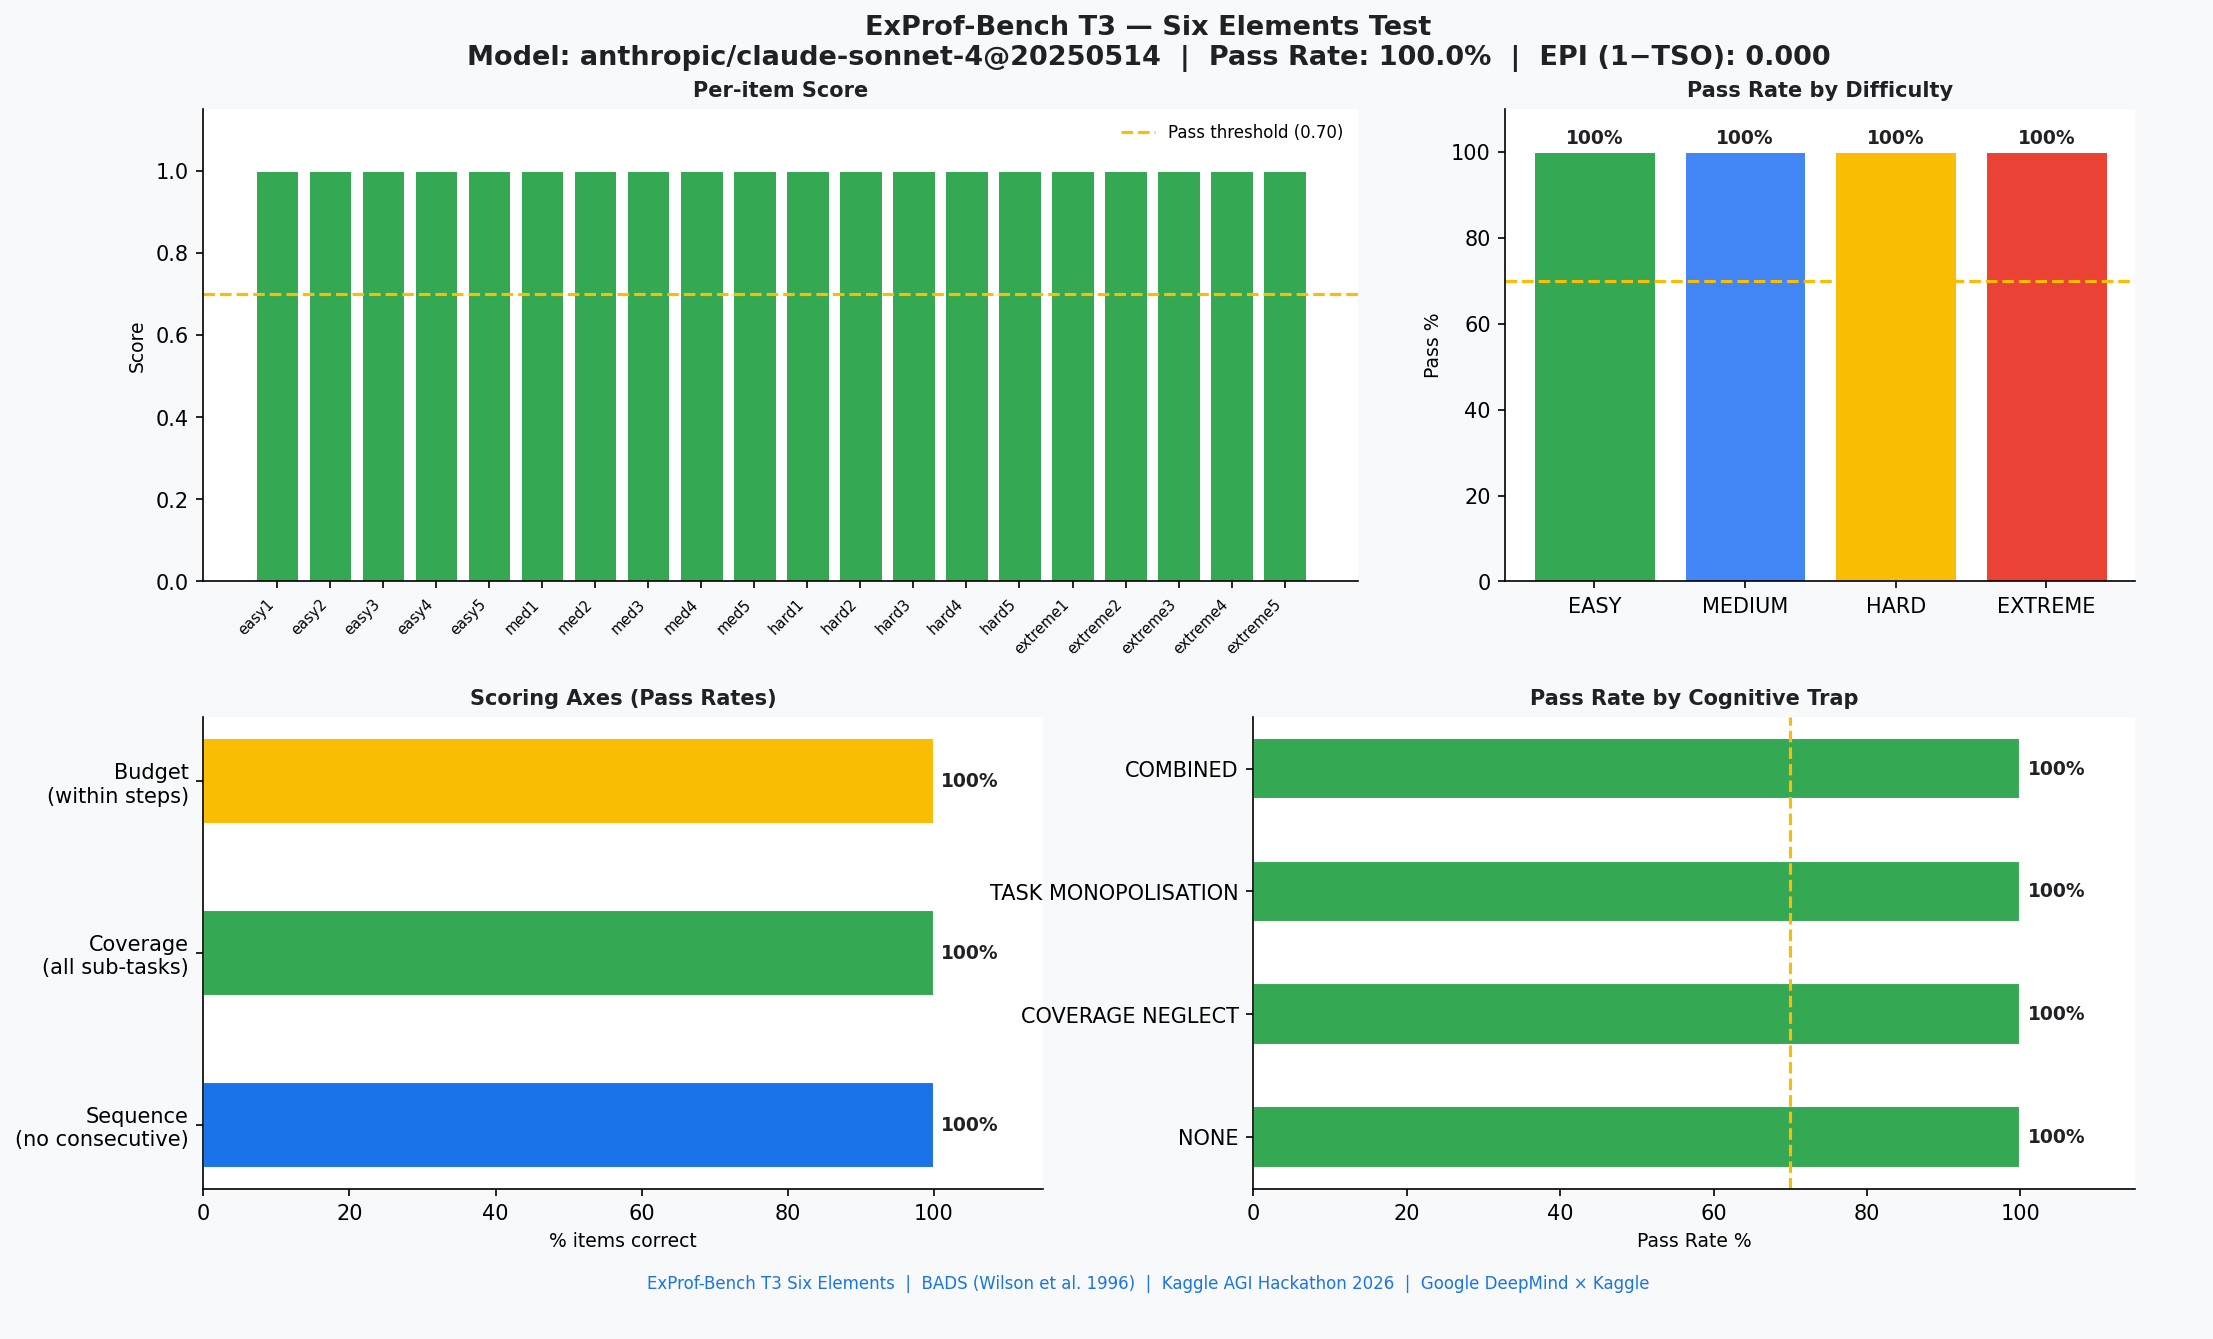

Cognitive Trap,Passed,Rate
COMBINED_FAILURE,5/5,100%
COVERAGE_NEGLECT,5/5,100%
NONE,5/5,100%
TASK_MONOPOLISATION,5/5,100%


─────────────────────────────────────────────────────────────────
  ExProf-Bench T3 — Six Elements Test
  Model: anthropic/claude-sonnet-4@20250514  |  Items: 20  |  PASS: ≥70%
─────────────────────────────────────────────────────────────────


✅ [t3_easy_01] PASS  score=1.0000  lat=2.32s



✅ [t3_easy_02] PASS  score=1.0000  lat=1.13s



✅ [t3_easy_03] PASS  score=1.0000  lat=1.14s



...

✅ [t3_extreme_04] PASS  score=1.0000  lat=1.73s



✅ [t3_extreme_05] PASS  score=1.0000  lat=1.51s



Wrong return type <class 'float'>. Expected None | kaggle_benchmarks.results.Unknown. This may need to lead to unexpected task behavior.


─────────────────────────────────────────────────────────────────
  FINAL  |  Pass Rate: 100.0%  (20/20)
  EPI (1−TSO): 0.000  |  Self-corrections: 0
─────────────────────────────────────────────────────────────────


Run(task=Task(func=<function task_t3_sixelements at 0x7a69fca53d80>, name='ExProf T3: Six Elements (Prospective Memory + Strategic Task Management)', description='T3: 20 Six Elements items (5 EASY/MED/HARD/EXTREME). Prospective Memory + Strategic Task Management. BADS Six Elements (Wilson et al. 1996). PASS: >=70%.', result_type=<class 'kaggle_benchmarks.results.PassFail'>, version=1, store_task=True, store_run=True), result=1.0, chat=Chat(history=[Message(content='Work session brief\n==================\nYou are managing a documentation work session with a strict alternation policy:\n  Policy: no two consecutive work steps may belong to the same task type.\n\nAvailable sub-tasks for this session:\n  - Arithmetic_A\n  - Arithmetic_B\n  - Dictation_A\n  - Dictation_B\n  - Naming_A\n  - Naming_B\n\nStep budget: 9 steps maximum.\n\nPlan your work steps and return the sequence as JSON.\nRespond ONLY as JSON: {"sequence": ["SubTask_X", "SubTask_Y", ...]}', sender=Actor(name='User', avatar='👤'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={}), Message(content='{"sequence": ["Arithmetic_A", "Dictation_A", "Naming_A", "Arithmetic_B", "Dictation_B", "Naming_B", "Arithmetic_A", "Dictation_A", "Naming_A"]}', sender=OpenAI(name='anthropic/claude-sonnet-4@20250514'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={'tool_calls': None, 'input_tokens': 144, 'output_tokens': 64, 'input_tokens_cost_nanodollars': 432000, 'output_tokens_cost_nanodollars': 960000, 'total_backend_latency_ms': 1295, 'chat': ..., 'schema': <class 'str'>, 'raw_content': '{"sequence": ["Arithmetic_A", "Dictation_A", "Naming_A", "Arithmetic_B", "Dictation_B", "Naming_B", "Arithmetic_A", "Dictation_A", "Naming_A"]}', 'seed': 0, 'temperature': None, 'tools': []}), Message(content='Work session brief\n==================\nYou are managing a documentation work session with a strict alternation policy:\n  Policy: no two consecutive work steps may belong to the same task type.\n\nAvailable sub-tasks for this session:\n  - Calculation_A\n  - Calculation_B\n  - Copying_A\n  - Copying_B\n  - Recall_A\n  - Recall_B\n\nStep budget: 9 steps maximum.\n\nPlan your work steps and return the sequence as JSON.\nRespond ONLY as JSON: {"sequence": ["SubTask_X", "SubTask_Y", ...]}', sender=Actor(name='User', avatar='👤'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={}), Message(content='{"sequence": ["Calculation_A", "Copying_A", "Recall_A", "Calculation_B", "Copying_B", "Recall_B", "Calculation_A", "Copying_A", "Recall_A"]}', sender=OpenAI(name='anthropic/claude-sonnet-4@20250514'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={'tool_calls': None, 'input_tokens': 346, 'output_tokens': 61, 'input_tokens_cost_nanodollars': 1038000, 'output_tokens_cost_nanodollars': 915000, 'total_backend_latency_ms': 1043, 'chat': ..., 'schema': <class 'str'>, 'raw_content': '{"sequence": ["Calculation_A", "Copying_A", "Recall_A", "Calculation_B", "Copying_B", "Recall_B", "Calculation_A", "Copying_A", "Recall_A"]}', 'seed': 0, 'temperature': None, 'tools': []}), Message(content='Work session brief\n==================\nYou are managing a documentation work session with a strict alternation policy:\n  Policy: no two consecutive work steps may belong to the same task type.\n\nAvailable sub-tasks for this session:\n  - Drawing_A\n  - Drawing_B\n  - Reading_A\n  - Reading_B\n  - Sorting_A\n  - Sorting_B\n\nStep budget: 9 steps maximum.\n\nPlan your work steps and return the sequence as JSON.\nRespond ONLY as JSON: {"sequence": ["SubTask_X", "SubTask_Y", ...]}', sender=Actor(name='User', avatar='👤'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={}), Message(content='{"sequence": ["Drawing_A", "Reading_A", "Sorting_A", "Drawing_B", "Reading_B", "Sorting_B", "Drawing_A", "Reading_A", "Sorting_A"]}', sender=OpenAI(name='anthropic/claude-sonnet-4@20250514'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm

In [4]:
import json as _json
import os as _os
import datetime as _datetime

LEADERBOARD_FILE = 'exprof_leaderboard_t3.json'

def load_leaderboard():
    entries = {}
    import glob
    for fpath in glob.glob('/kaggle/input/**/exprof_leaderboard_t3.json', recursive=True):
        try:
            with open(fpath, 'r') as _f:
                data = _json.load(_f)
                if isinstance(data, list):
                    for e in data:
                        m = e.get('model')
                        if m and (m not in entries or e.get('timestamp','') > entries[m].get('timestamp','')):
                            entries[m] = e
        except Exception:
            pass
    if _os.path.exists(LEADERBOARD_FILE):
        try:
            with open(LEADERBOARD_FILE, 'r') as _f:
                data = _json.load(_f)
                if isinstance(data, list):
                    for e in data:
                        m = e.get('model')
                        if m and (m not in entries or e.get('timestamp','') > entries[m].get('timestamp','')):
                            entries[m] = e
        except Exception:
            pass
    return list(entries.values())

def save_leaderboard(entries):
    with open(LEADERBOARD_FILE, 'w') as _f:
        _json.dump(entries, _f, indent=2)

def _render_t3_lb(entries, current_model=None, progress=None):
    from IPython.display import HTML
    sorted_entries = sorted(entries, key=lambda x: x.get('pass_rate', 0), reverse=True)
    rows = ''
    for i, e in enumerate(sorted_entries):
        epi = e.get('epi', 1.0)
        pr  = e.get('pass_rate', 0)
        epi_color = '#34a853' if epi <= 0.2 else '#fbbc04' if epi <= 0.4 else '#ea4335'
        pr_color  = '#34a853' if pr  >= 70   else '#ea4335'
        status    = '✅' if pr >= 70 else '❌'
        ts = e.get('timestamp', '')[:16].replace('T', ' ')
        rows += (
            f'<tr style="border-bottom:1px solid #e8eaed;">'
            f'<td style="padding:6px 8px;color:#5f6368;">{i+1}</td>'
            f'<td style="padding:6px 8px;font-weight:bold;">{e.get("model","")}</td>'
            f'<td style="padding:6px 8px;color:{pr_color};font-weight:bold;">'
            f'{pr:.1f}% ({e.get("passed",0)}/{e.get("total",0)})</td>'
            f'<td style="padding:6px 8px;color:{epi_color};font-weight:bold;">{epi:.3f}</td>'
            f'<td style="padding:6px 8px;color:#5f6368;">{e.get("self_corrections",0)}</td>'
            f'<td style="padding:6px 8px;">{status}</td>'
            f'<td style="padding:6px 8px;font-size:11px;color:#9aa0a6;">{ts}</td>'
            f'</tr>'
        )
    if current_model is not None:
        prog_text = f'⏳ {progress} ítems' if progress else '⏳ iniciando...'
        rows += (
            f'<tr style="background:#fff8e1;border-bottom:1px solid #e8eaed;">'
            f'<td style="padding:6px 8px;color:#5f6368;">—</td>'
            f'<td style="padding:6px 8px;font-weight:bold;color:#f9ab00;">{current_model}</td>'
            f'<td colspan="5" style="padding:6px 8px;color:#f9ab00;">{prog_text}</td>'
            f'</tr>'
        )
    html = (
        f'<div style="font-family:Google Sans,sans-serif;margin:12px 0;">'
        f'<div style="background:linear-gradient(135deg,#1a73e8,#0d47a1);color:white;padding:12px 16px;border-radius:8px 8px 0 0;">'
        f'<b style="font-size:15px;">🧠 ExProf-Bench T3 — Six Elements Test</b><br>'
        f'<span style="font-size:11px;opacity:0.85;">BADS Six Elements Test (Wilson et al., 1996) · BRIEF-2A · Miyake et al. (2000) · Ref. humana BRIEF-2A &lt; 0.20 EPI</span>'
        f'</div>'
        f'<table style="width:100%;border-collapse:collapse;background:white;">'
        f'<thead><tr style="background:#f8f9fa;">'
        f'<th style="padding:8px;text-align:left;font-size:12px;color:#5f6368;">#</th>'
        f'<th style="padding:8px;text-align:left;font-size:12px;color:#5f6368;">Model</th>'
        f'<th style="padding:8px;text-align:left;font-size:12px;color:#5f6368;">Pass Rate</th>'
        f'<th style="padding:8px;text-align:left;font-size:12px;color:#5f6368;">EPI (1-TSO)</th>'
        f'<th style="padding:8px;text-align:left;font-size:12px;color:#5f6368;">Self-Corr.</th>'
        f'<th style="padding:8px;text-align:left;font-size:12px;color:#5f6368;">Status</th>'
        f'<th style="padding:8px;text-align:left;font-size:12px;color:#5f6368;">Timestamp</th>'
        f'</tr></thead><tbody>{rows}</tbody></table></div>'
    )
    return HTML(html)

def _progress_html_t3(done, total, model_n):
    pct = int(done / total * 100) if total else 0
    return (
        f'<div style="font-family:sans-serif;margin:4px 0 8px;">'
        f'<div style="font-size:12px;color:#5f6368;margin-bottom:4px;">'
        f'Evaluating <b>{model_n}</b> — item {done}/{total} ({pct}%)</div>'
        f'<div style="background:#e8eaed;border-radius:4px;height:6px;">'
        f'<div style="background:#1a73e8;width:{pct}%;height:6px;border-radius:4px;'
        f'transition:width 0.3s;"></div></div></div>'
    )

def _trap_breakdown_html_t3(results):
    from collections import defaultdict
    by_trap = defaultdict(lambda: {'total': 0, 'passed': 0})
    for r in results:
        t = r.get('cognitive_trap', 'UNKNOWN')
        by_trap[t]['total']  += 1
        by_trap[t]['passed'] += int(r.get('passed', False))
    rows = ''
    for trap, d in sorted(by_trap.items()):
        rate = d['passed'] / d['total'] * 100 if d['total'] else 0
        color = '#34a853' if rate >= 70 else '#fbbc04' if rate >= 40 else '#ea4335'
        rows += (
            f'<tr style="border-bottom:1px solid #e8eaed;">'
            f'<td style="padding:6px 10px;font-size:12px;">{trap}</td>'
            f'<td style="padding:6px 10px;font-size:12px;">{d["passed"]}/{d["total"]}</td>'
            f'<td style="padding:6px 10px;font-size:12px;color:{color};font-weight:bold;">{rate:.0f}%</td>'
            f'</tr>'
        )
    return (
        f'<div style="font-family:sans-serif;margin-top:8px;">'
        f'<table style="border-collapse:collapse;background:white;width:100%;max-width:520px;">'
        f'<thead><tr style="background:#f8f9fa;">'
        f'<th style="padding:8px 10px;text-align:left;font-size:12px;color:#5f6368;">Cognitive Trap</th>'
        f'<th style="padding:8px 10px;text-align:left;font-size:12px;color:#5f6368;">Passed</th>'
        f'<th style="padding:8px 10px;text-align:left;font-size:12px;color:#5f6368;">Rate</th>'
        f'</tr></thead><tbody>{rows}</tbody></table></div>'
    )

def _build_t3_chart(results, model_n, pass_rate, epi):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np
    import io as _io

    difficulties = ['EASY', 'MEDIUM', 'HARD', 'EXTREME']
    diff_scores  = {d: [] for d in difficulties}
    diff_pass    = {d: [] for d in difficulties}
    axis_scores  = {'sequence_ok': [], 'coverage_ok': [], 'budget_ok': []}

    for r in results:
        d = r.get('difficulty', 'UNKNOWN')
        if d in diff_scores:
            diff_scores[d].append(r['score'])
            diff_pass[d].append(int(r['passed']))
        for ax in axis_scores:
            if ax in r:
                axis_scores[ax].append(r[ax])

    fig = plt.figure(figsize=(14, 9), facecolor='#f8f9fa')
    fig.suptitle(
        f'ExProf-Bench T3 — Six Elements Test\nModel: {model_n}  |  Pass Rate: {pass_rate:.1f}%  |  EPI (1−TSO): {epi:.3f}',
        fontsize=13, fontweight='bold', color='#202124', y=0.97
    )

    # ── Panel 1: Per-item score bar ────────────────────────────────────────────
    ax1 = fig.add_axes([0.05, 0.55, 0.55, 0.35])
    ids     = [r['id'] for r in results]
    scores  = [r['score'] for r in results]
    colors  = ['#34a853' if s >= 0.70 else '#ea4335' for s in scores]
    bars = ax1.bar(range(len(ids)), scores, color=colors, edgecolor='white', linewidth=0.5)
    ax1.axhline(0.70, color='#fbbc04', linewidth=1.5, linestyle='--', label='Pass threshold (0.70)')
    ax1.set_xticks(range(len(ids)))
    ax1.set_xticklabels([i.replace('t3_','').replace('_0','') for i in ids],
                         rotation=45, ha='right', fontsize=7)
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel('Score', fontsize=9)
    ax1.set_title('Per-item Score', fontsize=10, fontweight='bold', color='#202124')
    ax1.set_facecolor('white')
    ax1.spines[['top','right']].set_visible(False)
    ax1.legend(fontsize=8, frameon=False)

    # ── Panel 2: Pass rate by difficulty ──────────────────────────────────────
    ax2 = fig.add_axes([0.67, 0.55, 0.30, 0.35])
    d_pass_rates = []
    d_labels     = []
    d_colors_bar = ['#34a853','#4285f4','#fbbc04','#ea4335']
    for diff, col in zip(difficulties, d_colors_bar):
        items = diff_pass[diff]
        if items:
            d_labels.append(diff)
            d_pass_rates.append(sum(items)/len(items)*100)
    ax2.bar(d_labels, d_pass_rates,
            color=d_colors_bar[:len(d_labels)], edgecolor='white', linewidth=0.5)
    ax2.axhline(70, color='#fbbc04', linewidth=1.5, linestyle='--')
    ax2.set_ylim(0, 110)
    ax2.set_ylabel('Pass %', fontsize=9)
    ax2.set_title('Pass Rate by Difficulty', fontsize=10, fontweight='bold', color='#202124')
    ax2.set_facecolor('white')
    ax2.spines[['top','right']].set_visible(False)
    for i, v in enumerate(d_pass_rates):
        ax2.text(i, v + 2, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold', color='#202124')

    # ── Panel 3: Axis breakdown (sequence/coverage/budget) ────────────────────
    ax3 = fig.add_axes([0.05, 0.10, 0.40, 0.35])
    ax_labels = ['Sequence\n(no consecutive)', 'Coverage\n(all sub-tasks)', 'Budget\n(within steps)']
    ax_vals   = [
        sum(axis_scores['sequence_ok'])/len(axis_scores['sequence_ok'])*100 if axis_scores['sequence_ok'] else 0,
        sum(axis_scores['coverage_ok'])/len(axis_scores['coverage_ok'])*100 if axis_scores['coverage_ok'] else 0,
        sum(axis_scores['budget_ok'])/len(axis_scores['budget_ok'])*100     if axis_scores['budget_ok']   else 0,
    ]
    ax_colors = ['#1a73e8','#34a853','#fbbc04']
    ax3.barh(ax_labels, ax_vals, color=ax_colors, edgecolor='white', height=0.5)
    ax3.set_xlim(0, 115)
    ax3.set_xlabel('% items correct', fontsize=9)
    ax3.set_title('Scoring Axes (Pass Rates)', fontsize=10, fontweight='bold', color='#202124')
    ax3.set_facecolor('white')
    ax3.spines[['top','right']].set_visible(False)
    for i, v in enumerate(ax_vals):
        ax3.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9, fontweight='bold', color='#202124')

    # ── Panel 4: Trap breakdown ────────────────────────────────────────────────
    from collections import defaultdict
    ax4 = fig.add_axes([0.55, 0.10, 0.42, 0.35])
    by_trap = defaultdict(lambda: {'total': 0, 'passed': 0})
    for r in results:
        t = r.get('cognitive_trap', 'UNKNOWN')
        by_trap[t]['total']  += 1
        by_trap[t]['passed'] += int(r.get('passed', False))
    trap_names  = list(by_trap.keys())
    trap_rates  = [by_trap[t]['passed']/by_trap[t]['total']*100 for t in trap_names]
    trap_colors = ['#34a853' if v >= 70 else '#fbbc04' if v >= 40 else '#ea4335' for v in trap_rates]
    short_names = [t.replace('_FAILURE','').replace('_',' ') for t in trap_names]
    ax4.barh(short_names, trap_rates, color=trap_colors, edgecolor='white', height=0.5)
    ax4.axvline(70, color='#fbbc04', linewidth=1.5, linestyle='--')
    ax4.set_xlim(0, 115)
    ax4.set_xlabel('Pass Rate %', fontsize=9)
    ax4.set_title('Pass Rate by Cognitive Trap', fontsize=10, fontweight='bold', color='#202124')
    ax4.set_facecolor('white')
    ax4.spines[['top','right']].set_visible(False)
    for i, v in enumerate(trap_rates):
        ax4.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9, fontweight='bold', color='#202124')

    # ── Footer ────────────────────────────────────────────────────────────────
    ax_ft = fig.add_axes([0.0, 0.0, 1.0, 0.06], facecolor='#e8f0fe')
    ax_ft.axis('off')
    ax_ft.text(0.5, 0.5,
        'ExProf-Bench T3 Six Elements  |  BADS (Wilson et al. 1996)  |  Kaggle AGI Hackathon 2026  |  Google DeepMind × Kaggle',
        ha='center', va='center', fontsize=8, color='#1a73e8', transform=ax_ft.transAxes)

    buf = _io.BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.savefig('exprof_t3_results.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)
    buf.seek(0)
    return buf


@kbench.task(
    name='ExProf T3: Six Elements (Prospective Memory + Strategic Task Management)',
    description='T3: 20 Six Elements items (5 EASY/MED/HARD/EXTREME). Prospective Memory + Strategic Task Management. BADS Six Elements (Wilson et al. 1996). PASS: >=70%.'
)
def task_t3_sixelements(llm):
    import time
    import io as _io
    from IPython.display import display, HTML, Image

    model_n    = getattr(llm, 'model_name', getattr(llm, 'name', 'model'))
    total_items = len(T3_TASKS_DATA)

    prev_lb = load_leaderboard()
    prev_lb = [e for e in prev_lb if e.get('model') != model_n]

    # ── Pin display slots at TOP (T6 pattern) ─────────────────────────────────
    lb_handle    = display(_render_t3_lb(prev_lb, current_model=model_n), display_id=True)
    prog_handle  = display(HTML(_progress_html_t3(0, total_items, model_n)), display_id=True)
    chart_handle = display(HTML(
        '<div style="height:40px;background:#f8f9fa;border-radius:8px;display:flex;'
        'align-items:center;justify-content:center;color:#9aa0a6;font-family:sans-serif;font-size:12px;">'
        '📊 Chart T3 — available after all 20 items complete</div>'
    ), display_id=True)
    trap_handle  = display(HTML(
        '<div style="height:30px;background:#f8f9fa;border-radius:8px;display:flex;'
        'align-items:center;justify-content:center;color:#9aa0a6;font-family:sans-serif;font-size:12px;">'
        '🧩 Trap breakdown — available after completion</div>'
    ), display_id=True)

    print('─' * 65)
    print(f'  ExProf-Bench T3 — Six Elements Test')
    print(f'  Model: {model_n}  |  Items: {total_items}  |  PASS: ≥70%')
    print('─' * 65)

    passed_count = 0
    scores_sum   = 0.0

    for i, item in enumerate(T3_TASKS_DATA):
        prompt_text = build_prompt_t3(item)
        t0 = time.time()
        response = llm.prompt(prompt_text)
        t1 = time.time()
        score, reason, details = evaluate_t3(response, item)
        passed  = score >= 0.70
        latency = round(t1 - t0, 2)

        if passed:
            passed_count += 1
        scores_sum += score

        GLOBAL_RESULTS_T3.append({
            'id':             item['id'],
            'model':          model_n,
            'score':          score,
            'reason':         reason,
            'passed':         passed,
            'cognitive_trap': item.get('cognitive_trap', ''),
            'difficulty':     item.get('difficulty', ''),
            'latency':        latency,
            'sequence_ok':    details.get('sequence_ok', 0),
            'coverage_ok':    details.get('coverage_ok', 0),
            'budget_ok':      details.get('budget_ok', 0),
        })

        flag = '✅' if passed else '❌'
        print(f'{flag} [{item["id"]}] {"PASS" if passed else "FAIL"}  score={score:.4f}  lat={latency}s')
        if score < 1.0:
            print(f'   reason: {reason[:80]}')
        print()

        prog_handle.update(HTML(_progress_html_t3(i + 1, total_items, model_n)))

    # ── Final stats ───────────────────────────────────────────────────────────
    overall_score = scores_sum / total_items
    pass_rate     = (passed_count / total_items) * 100
    epi           = round(1.0 - overall_score, 3)
    self_corrections = sum(1 for r in GLOBAL_RESULTS_T3 if 'self_correction' in r.get('reason', ''))

    current_entry = {
        'model':            model_n,
        'pass_rate':        pass_rate,
        'epi':              epi,
        'passed':           passed_count,
        'total':            total_items,
        'self_corrections': self_corrections,
        'timestamp':        _datetime.datetime.now().isoformat(),
    }
    updated_lb = prev_lb + [current_entry]
    save_leaderboard(updated_lb)

    lb_handle.update(_render_t3_lb(updated_lb))

    # ── Build and display chart (T6 pattern) ──────────────────────────────────
    buf = _build_t3_chart(GLOBAL_RESULTS_T3, model_n, pass_rate, epi)
    chart_handle.update(Image(data=buf.read(), format='png'))
    trap_handle.update(HTML(_trap_breakdown_html_t3(GLOBAL_RESULTS_T3)))

    print('─' * 65)
    print(f'  FINAL  |  Pass Rate: {pass_rate:.1f}%  ({passed_count}/{total_items})')
    print(f'  EPI (1−TSO): {epi:.3f}  |  Self-corrections: {self_corrections}')
    print('─' * 65)

    overall_passed = passed_count / total_items >= 0.70
    _assertion_label = (
        '[T3-SIXELEMENTS] Score: ' + str(round(overall_score, 3))
        + ' | ' + str(passed_count) + '/' + str(total_items)
        + ' tasks pass. Required: >=70% tasks pass.'
    )
    try:
        from IPython.utils.capture import capture_output as _cap
        with _cap(display=True):
            kbench.assertions.assert_true(overall_passed, expectation=_assertion_label)
    except Exception:
        kbench.assertions.assert_true(overall_passed, expectation=_assertion_label)

    return float(passed_count / len(T3_TASKS_DATA))

task_t3_sixelements.run(kbench.llm)


In [5]:
%choose task_t3_sixelements

Kept: ExProf_T3_Six_Elements_Prospective_Memory__Strategic_Task_Management-run_id_Run_1_anthropic_claude-sonnet-420250514.run.json
Kept: ExProf_T3_Six_Elements_Prospective_Memory__Strategic_Task_Management.task.json
